In [34]:
import os
import qsprpred
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import torch

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd
from qsprpred.data.descriptors.sets import RDKitDescs
from MolEval import MolEmb 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from qsprpred.data.descriptors.sets import RDKitDescs

In [38]:
X1 = pd.read_csv("A2AR/mod_data/X1.1", index_col="QSPRID")
X2 = pd.read_csv("A2AR/mod_data/X2.1", index_col="QSPRID")
X3 = pd.read_csv("A2AR/mod_data/X3.1", index_col="QSPRID")
y1 = pd.read_csv("A2AR/mod_data/y1.1", index_col="QSPRID")
y2 = pd.read_csv("A2AR/mod_data/y2.1", index_col="QSPRID")
y3 = pd.read_csv("A2AR/mod_data/y3.1", index_col="QSPRID")


In [39]:
X1.columns = X1.columns.astype(str)
X2.columns = X2.columns.astype(str)
X3.columns = X3.columns.astype(str)

imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
X1 = imp_mean.fit_transform(X1)
X2 = imp_mean.transform(X2)
X3 = imp_mean.transform(X3)
scaler = StandardScaler()
scaler.fit(X1)
X1 = scaler.transform(X1)
X2 = scaler.transform(X2)
X3 = scaler.transform(X3)

In [37]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=1, random_state=42)
X1, y1 = smote.fit_resample(X1, y1)
display(pd.DataFrame(X1))

KeyboardInterrupt: 

In [40]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
pca.fit(X1)

PCA(n_components=0.95)

In [41]:
cum_var = np.cumsum(pca.explained_variance_ratio_)

# Např. najít počet komponent, které vysvětlí 95 % rozptylu
n_components = np.argmax(cum_var >= 0.95) + 1

In [42]:
n_components

851

In [43]:
from sklearn.decomposition import PCA
pca = PCA(n_components=n_components)
X1 = pca.fit_transform(X1)
X2 = pca.transform(X2)
X3 = pca.transform(X3)

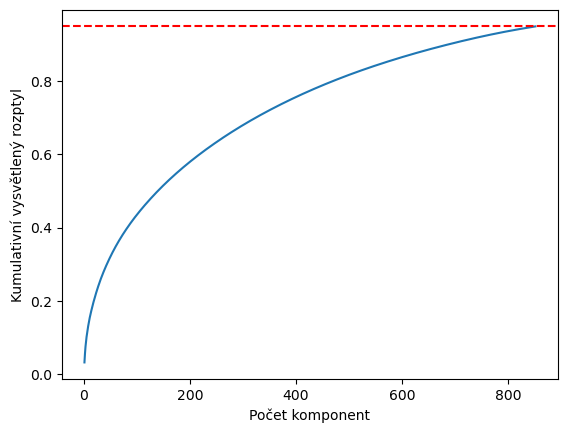

In [44]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(cum_var)+1), cum_var)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('Počet komponent')
plt.ylabel('Kumulativní vysvětlený rozptyl')
plt.show()

In [45]:
import lightgbm as lgb

rf = lgb.LGBMClassifier(random_state=69)
rf.fit(X1, y1)

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:132: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


LGBMClassifier(random_state=69)

In [46]:
pred = rf.predict(X2)

In [47]:
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score

print("Acc:", accuracy_score(pred, y2))
print("Mcc:", matthews_corrcoef(pred, y2))

Acc: 0.9630086313193588
Mcc: 0.0


In [48]:
pred = rf.predict(X3)
print("Acc:", accuracy_score(pred, y3))
print("Mcc:", matthews_corrcoef(pred, y3))

Acc: 0.9675925925925926
Mcc: 0.2539707859042205


In [15]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score, roc_auc_score # Přidáme import pro ROC AUC
import pandas as pd
import optuna



def objective(trial, X_train, y_train, X_val, y_val):
    """Definice cílové funkce pro Optunu"""

    # Návrh hyperparametrů
    params = {
        'objective': 'binary',
        'metric': 'auc',  # Používáme AUC pro optimalizaci
        'boosting_type': trial.suggest_categorical('boosting_type', ['gbdt', 'dart']),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'max_depth': trial.suggest_int('max_depth', 5, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.8, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.8, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 0.1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 0.1),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
        'verbose': -1,  # Potlačení logování
        'random_state': 69,  # Přidáno pro reprodukovatelnost
    }

    model = lgb.LGBMClassifier(**params)
    model.fit(X_train, y_train.Y)
    y_pred = model.predict(X_val)
    mcc = matthews_corrcoef(y_val.Y, y_pred)  # Používáme MCC

    return mcc


In [49]:
study = optuna.create_study(
    study_name="A2AR_lgb_2",  # jméno pro pozdější načtení
    direction="maximize",
    sampler=optuna.samplers.NSGAIISampler(),
    storage="sqlite:///optuna_results.db",
    load_if_exists=True  # pokud už existuje, nepřepíše ji
)

# Spusť optimalizaci
study.optimize(
    lambda trial: objective(trial, X1, y1, X2, y2),
    n_trials=1000
)
print("Best MCC:", study.best_value)
print("Best parameters:", study.best_params)

# Pokud chceš F1 a ACC u nejlepšího modelu:
print("Best F1:", study.best_trial.user_attrs["f1"])
print("Best ACC:", study.best_trial.user_attrs["acc"])

[I 2025-05-18 16:04:30,258] Using an existing study with name 'A2AR_lgb_2' instead of creating a new one.
[I 2025-05-18 16:05:01,033] Trial 1814 finished with value: 0.0 and parameters: {'boosting_type': 'dart', 'n_estimators': 372, 'learning_rate': 0.03595959173663884, 'num_leaves': 58, 'max_depth': 9, 'min_child_samples': 89, 'subsample': 0.9200553110554466, 'colsample_bytree': 0.8158505974320746, 'reg_alpha': 0.002831853342273649, 'reg_lambda': 0.02839394106327039, 'class_weight': None}. Best is trial 0 with value: 0.0.
[I 2025-05-18 16:05:10,798] Trial 1815 finished with value: -0.006886405639653407 and parameters: {'boosting_type': 'gbdt', 'n_estimators': 238, 'learning_rate': 0.09291149019321582, 'num_leaves': 52, 'max_depth': 5, 'min_child_samples': 30, 'subsample': 0.8886335390390901, 'colsample_bytree': 0.847870099309823, 'reg_alpha': 0.05485973473876704, 'reg_lambda': 0.08524488918187223, 'class_weight': None}. Best is trial 0 with value: 0.0.
[I 2025-05-18 16:05:27,579] Tria

AssertionError: Should not reach.

In [17]:
import numpy as np
best_params = study.best_params

In [22]:
best_params

{'boosting_type': 'gbdt',
 'n_estimators': 440,
 'learning_rate': 0.05471217046340078,
 'num_leaves': 49,
 'max_depth': 5,
 'min_child_samples': 28,
 'subsample': 0.8574084346561166,
 'colsample_bytree': 0.9401653598842541,
 'reg_alpha': 0.07671499339187349,
 'reg_lambda': 0.0020932534329589194,
 'class_weight': 'balanced'}

In [23]:
rf = lgb.LGBMClassifier(**best_params, seed=69)
rf.fit(X1, y1.Y)

LGBMClassifier(class_weight='balanced', colsample_bytree=0.9401653598842541,
               learning_rate=0.05471217046340078, max_depth=5,
               min_child_samples=28, n_estimators=440, num_leaves=49,
               reg_alpha=0.07671499339187349, reg_lambda=0.0020932534329589194,
               seed=69, subsample=0.8574084346561166)

In [24]:
pred = rf.predict(X2)

print("Acc:", accuracy_score(pred, y2))
print("F1:", f1_score(pred, y2))
print("Mcc:", matthews_corrcoef(pred, y2))

Acc: 0.9630086313193588
F1: 0.9811557788944724
Mcc: 0.0


In [25]:
pred_test = rf.predict(X3)

print("Acc:", accuracy_score(pred_test, y3))
print("F1:", f1_score(pred_test, y3))
print("Mcc:", matthews_corrcoef(pred_test, y3))

Acc: 0.9652777777777778
F1: 0.9823321554770318
Mcc: 0.0


In [27]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(pred, y2)

In [28]:
cm

array([[  0,   0],
       [ 30, 781]])

In [32]:
y1.Y.sum()/y1.Y.count()

0.5